In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import figure
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [2]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
DATASET_PATH = "../dataset/bccc-cpacket-cloud-ddos-2024-merged.parquet"

df = pd.read_parquet(DATASET_PATH)

In [4]:
df.shape

(540494, 319)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 540494 entries, 0 to 540493
Columns: 319 entries, src_port to activity
dtypes: float32(261), int16(9), int32(20), int64(2), int8(25), str(2)
memory usage: 627.3 MB


In [6]:
string_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
string_cols

['label', 'activity']

In [7]:
df['activity'].nunique()

26

In [8]:
print(df['activity'].value_counts().sum())

df['activity'].value_counts()

540494


activity
Benign                        301014
Attack-TCP-BYPass-V1          134110
Benign-Web_Browsing_HTTP-S     29376
Suspicious                     20880
Benign-Systemic                 9342
Benign-Telnet                   4766
Attack-TCP-Flag-SYN             3147
Attack-TCP-Flag-ACK             3135
Attack-TCP-Flag-ACK-PSH         3109
Attack-Killer-TCP               3046
Attack-TCP-Valid-SYN            3003
Attack-TCP-Flag-SYN-ACK         2990
Attack-TCP-IGMP                 2960
Attack-TCP-Flag-MIX             2919
Attack-Killall-v2               2824
Attack-TCP-SYN                  2739
Attack-TCP-Control              2491
Benign-SSH                      1968
Benign-Email-Send               1281
Benign-Email-Receive            1084
Attack-TCP-Flag-SYN-TIME         980
Attack-TCP-Flag-SYN-TFO          843
Attack-TCP-Flag-OSYNP            758
Attack-TCP-Flag-OSYN             757
Attack-TCP-Flag-RST-ACK          625
Benign-FTP                       347
Name: count, dtype: int64

In [9]:
df = df.drop(columns=['activity'])

In [10]:
df.head(5)

,src_port,dst_port,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,...,min_fwd_payload_bytes_delta_len,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label
0,54573,25094,0.000063,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,25094,54573,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,54573,25094,0.000028,3,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,9147,18060,0.000055,3,2,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,18060,9147,0.000000,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [11]:
for col in df.columns:
    print(col)

src_port
dst_port
duration
packets_count
fwd_packets_count
bwd_packets_count
total_payload_bytes
fwd_total_payload_bytes
bwd_total_payload_bytes
payload_bytes_max
payload_bytes_min
payload_bytes_mean
payload_bytes_std
payload_bytes_variance
payload_bytes_median
payload_bytes_skewness
payload_bytes_cov
payload_bytes_mode
fwd_payload_bytes_max
fwd_payload_bytes_min
fwd_payload_bytes_mean
fwd_payload_bytes_std
fwd_payload_bytes_variance
fwd_payload_bytes_median
fwd_payload_bytes_skewness
fwd_payload_bytes_cov
fwd_payload_bytes_mode
bwd_payload_bytes_max
bwd_payload_bytes_min
bwd_payload_bytes_mean
bwd_payload_bytes_std
bwd_payload_bytes_variance
bwd_payload_bytes_median
bwd_payload_bytes_skewness
bwd_payload_bytes_cov
bwd_payload_bytes_mode
total_header_bytes
max_header_bytes
min_header_bytes
mean_header_bytes
std_header_bytes
median_header_bytes
skewness_header_bytes
cov_header_bytes
mode_header_bytes
variance_header_bytes
fwd_total_header_bytes
fwd_max_header_bytes
fwd_min_header_bytes


In [12]:
df.describe()

,src_port,dst_port,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,payload_bytes_max,...,cov_bwd_payload_bytes_delta_len,min_fwd_payload_bytes_delta_len,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len
count,540494.000000,540494.000000,540494.000000,5.404940e+05,5.404940e+05,5.404940e+05,5.404940e+05,5.404940e+05,5.404940e+05,540494.000000,...,540494.000000,540494.000000,540494.000000,540494.000000,540494.000000,5.404940e+05,540494.000000,540494.000000,540494.000000,540494.000000
mean,42256.697427,24618.095415,0.237969,1.869889e+01,5.484738e+00,1.321415e+01,2.024913e+04,2.954250e+03,1.729487e+04,2.659815,...,2.551771,-1.179016,1.092710,-0.045987,-0.816701,2.572928e+02,0.683516,-0.025944,-0.000270,0.480301
std,15823.578431,20865.794262,9.947224,5.620174e+03,1.683385e+03,4.597685e+03,6.977092e+06,2.134364e+06,6.642618e+06,51.832596,...,960.238342,29.584854,29.106281,8.374863,22.682816,7.558142e+03,16.025793,8.065406,0.151881,197.925171
min,2.000000,1.000000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,-9073.369141,-1460.000000,-970.000000,-970.000000,-1460.000000,0.000000e+00,0.000000,-970.000000,-104.726799,-7541.995117
25%,41063.000000,5060.000000,0.000000,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,45094.000000,18784.000000,0.000000,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,53083.000000,44756.000000,0.000092,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,65534.000000,65535.000000,3570.692627,2.524044e+06,1.097428e+06,2.171786e+06,3.166384e+09,1.569076e+09,3.166383e+09,1460.000000,...,655582.562500,1368.000000,1460.000000,1368.000000,1368.000000,1.338966e+06,1157.137085,1368.000000,3.875500,138843.906250


In [13]:
df['label'].unique()

<ArrowStringArray>
['Benign', 'Attack', 'Suspicious']
Length: 3, dtype: str

In [14]:
df['label'].value_counts()

label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='label'>

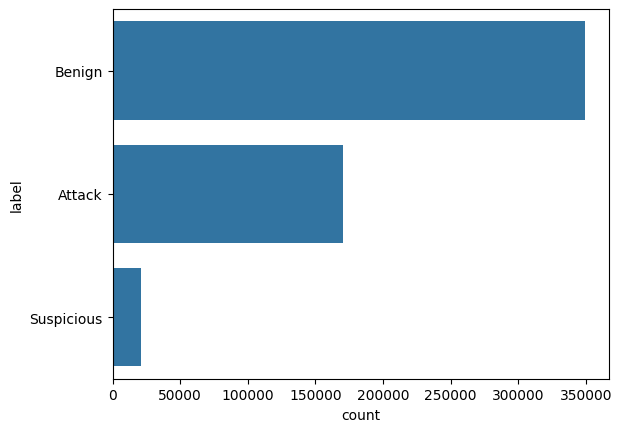

In [15]:
sns.countplot(df['label'])

In [16]:
df.isna().sum()

src_port                                0
dst_port                                0
duration                                0
packets_count                           0
fwd_packets_count                       0
                                       ..
std_fwd_payload_bytes_delta_len         0
median_fwd_payload_bytes_delta_len      0
skewness_fwd_payload_bytes_delta_len    0
cov_fwd_payload_bytes_delta_len         0
label                                   0
Length: 318, dtype: int64

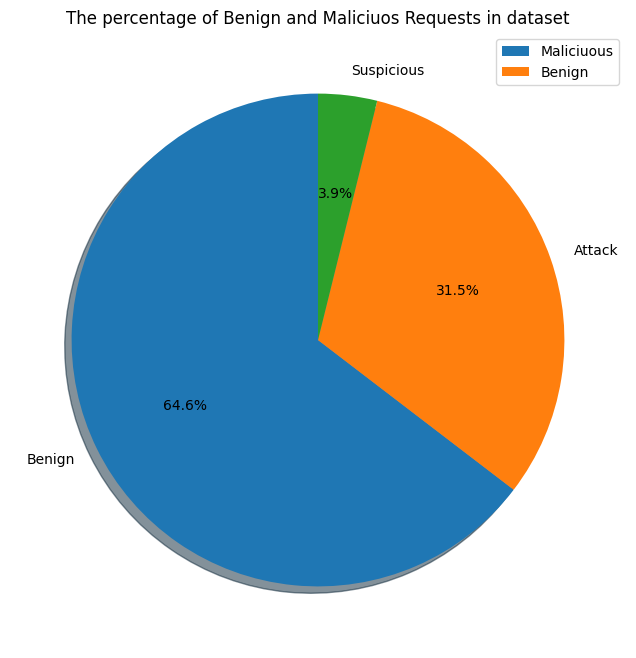

In [17]:
counts_dict = dict(df.label.value_counts())

labels = ["Benign", "Attack", "Suspicious"]
sizes = [
    counts_dict["Benign"], 
    counts_dict["Attack"],
    counts_dict["Suspicious"]
]
plt.figure(figsize = (13,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.legend(["Maliciuous", "Benign"])
plt.title('The percentage of Benign and Maliciuos Requests in dataset')
plt.show()

In [18]:
df['src_port'].dtype

dtype('int32')

In [19]:
df.src_port.nunique()

45330

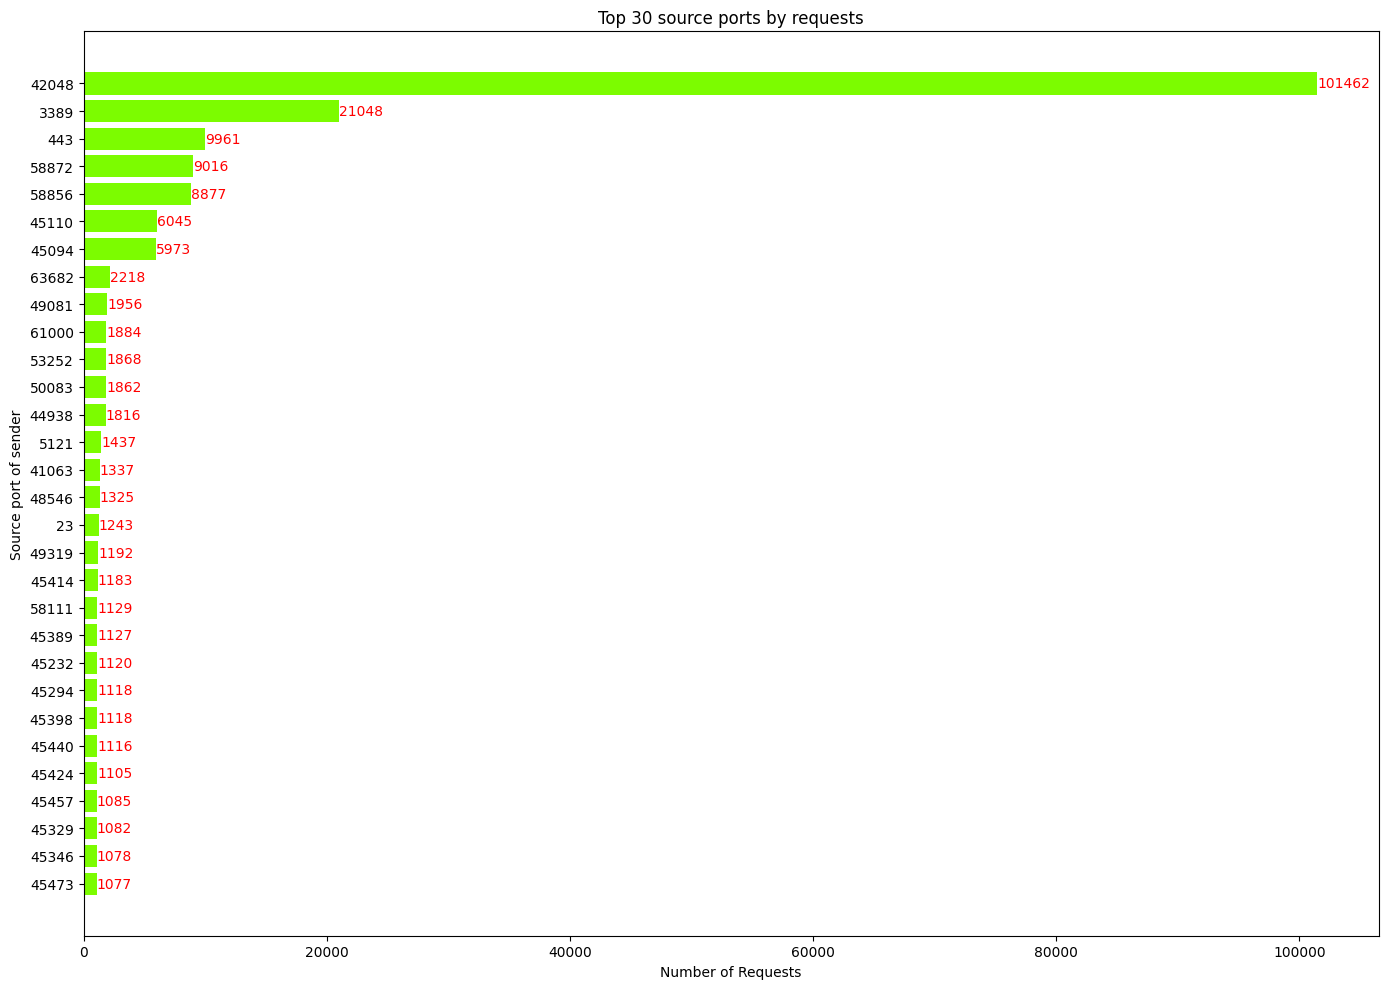

In [20]:
top_n = 30
counts = df["src_port"].value_counts().head(top_n).sort_values()

plt.figure(figsize=(14, 10), dpi=100)
plt.barh(counts.index.astype(str), counts.values, color="lawngreen")
plt.xlabel("Number of Requests")
plt.ylabel("Source port of sender")
plt.title(f"Top {top_n} source ports by requests")

for idx, val in enumerate(counts.values):
    plt.text(val, idx, str(val), va="center", color="r", size=10)
    
plt.tight_layout()

In [21]:
attack = df[df["label"] == "Attack"]

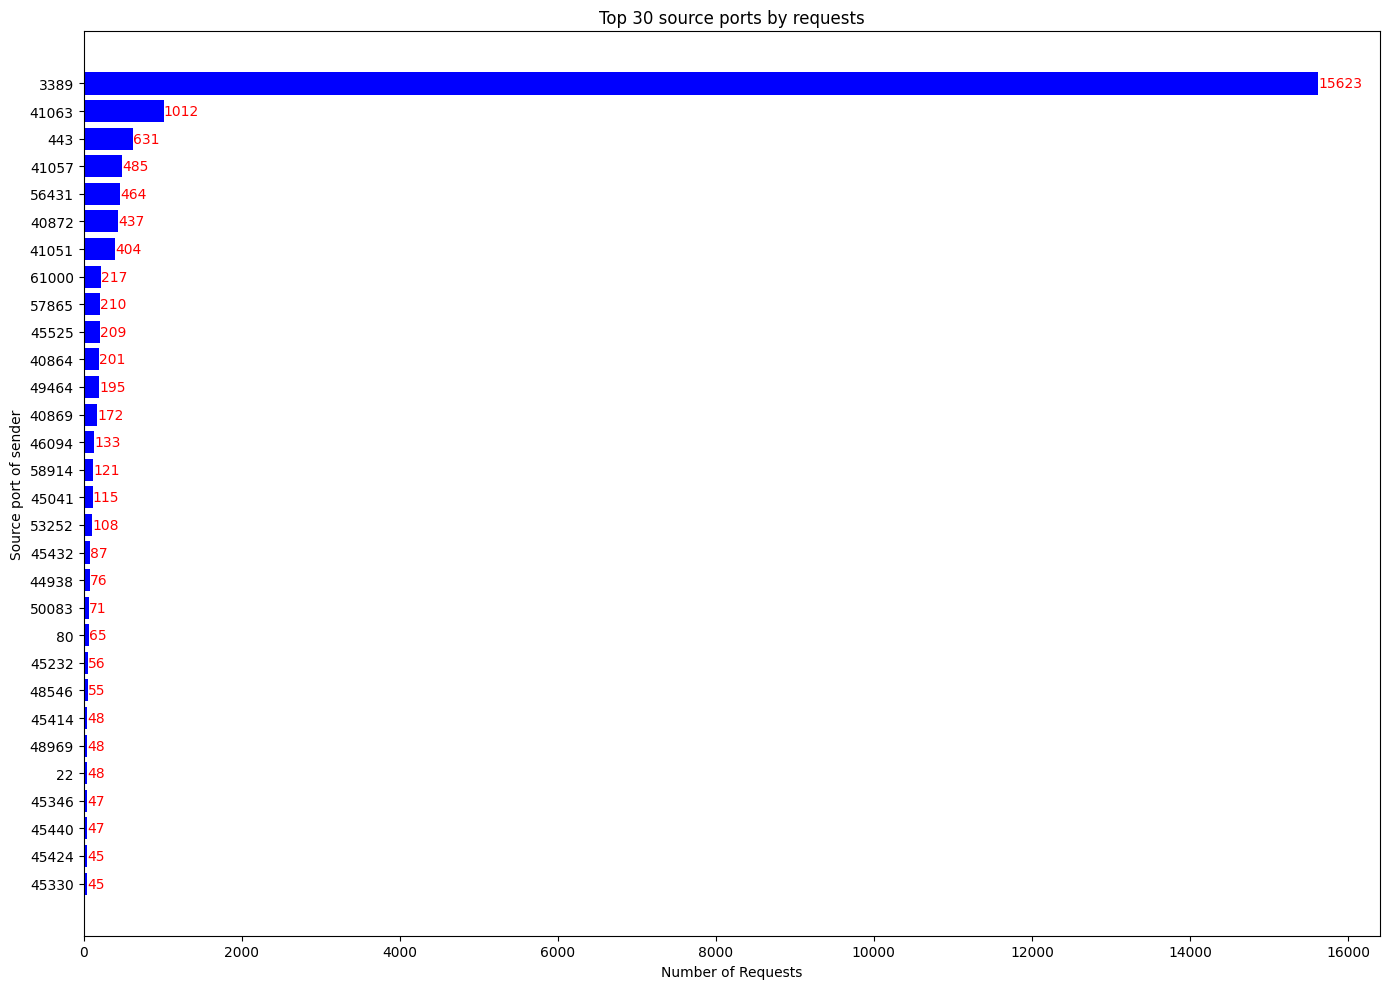

In [22]:
top_n = 30
counts = attack.src_port.value_counts().head(top_n).sort_values()

plt.figure(figsize=(14, 10), dpi=100)
plt.barh(counts.index.astype(str), counts.values, color="blue")
plt.xlabel("Number of Requests")
plt.ylabel("Source port of sender")
plt.title(f"Top {top_n} source ports by requests")

for idx, val in enumerate(counts.values):
    plt.text(val, idx, str(val), va="center", color="r", size=10)
    
plt.tight_layout()

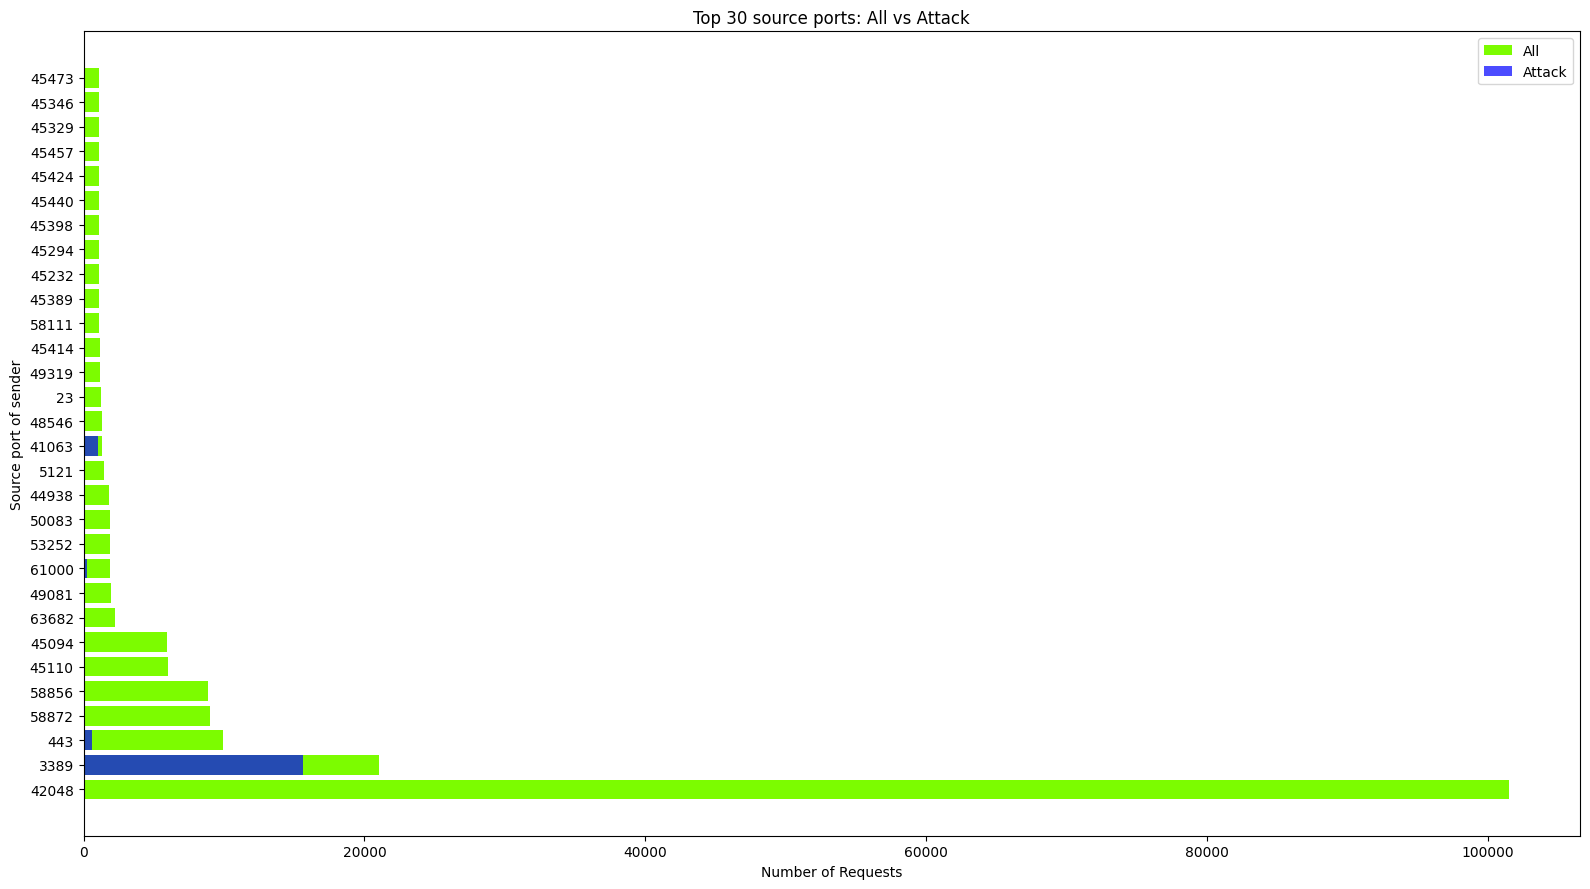

In [23]:
top_n = 30
all_counts = df["src_port"].value_counts().head(top_n)
attack_counts = df[df["label"] == "Attack"]["src_port"].value_counts()

ports = all_counts.index.astype(str)
attack_aligned = attack_counts.reindex(all_counts.index).fillna(0)

plt.figure(figsize=(16, 9), dpi=100)
y = range(len(ports))
plt.barh(y, all_counts.values, color="lawngreen", label="All")
plt.barh(y, attack_aligned.values, color="blue", alpha=0.7, label="Attack")

plt.yticks(y, ports)
plt.xlabel("Number of Requests")
plt.ylabel("Source port of sender")
plt.title(f"Top {top_n} source ports: All vs Attack")
plt.legend()
plt.tight_layout()

In [24]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [25]:
df.label.unique()

array([1, 0, 2])

In [26]:
df.label.value_counts()

# benign 64%
# attack 31%
# suspicious 3%

label
1    349178
0    170436
2     20880
Name: count, dtype: int64

In [27]:
string_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
string_cols

[]

In [28]:
X = df.drop(['label'], axis=1)
y = df['label']

In [29]:
# Step 1: Hold out 20% as test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: From remaining 80%, use 25% as validation → final split: 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [31]:
corr_matrix = X.corr().abs()

In [32]:
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
X.drop(columns=high_corr_cols, inplace=True)

In [33]:
zero_var_cols = [col for col in X.columns if X[col].nunique() <= 1]
X.drop(columns=zero_var_cols, inplace=True)
print(f"[Prep] Dropped {len(zero_var_cols)} zero-variance columns.")

[Prep] Dropped 3 zero-variance columns.


In [34]:
# 'balanced' mode: weight_c = n_samples / (n_classes * count_c)
# Suspicious (3.9%) gets ~16x the weight of Benign (64.6%)
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

In [36]:
model = RandomForestClassifier(
    # --- Regularization for 319 features ---
    n_estimators=1000,            # Number of trees
    max_depth=6,                  # Shallow trees = less overfitting on noisy features
    min_samples_split=5,          # Requires 5 samples to split — avoids splits on rare noise
    max_features='sqrt',          # Similar to colsample_bytree effect
    bootstrap=True,               # Row subsampling per tree
    
    # --- Performance ---
    n_jobs=-1,                    # Use all processors
    random_state=42,
    verbose=0,
    )

In [39]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,       # Apply class imbalance correction
)

print("Model training completed.")

Model training completed.



=== Classification Report ===
              precision    recall  f1-score   support

      Attack     0.9859    0.8107    0.8898     34087
      Benign     0.9885    0.9144    0.9500     69836
  Suspicious     0.2629    0.9734    0.4140      4176

    accuracy                         0.8840    108099
   macro avg     0.7458    0.8995    0.7513    108099
weighted avg     0.9596    0.8840    0.9103    108099



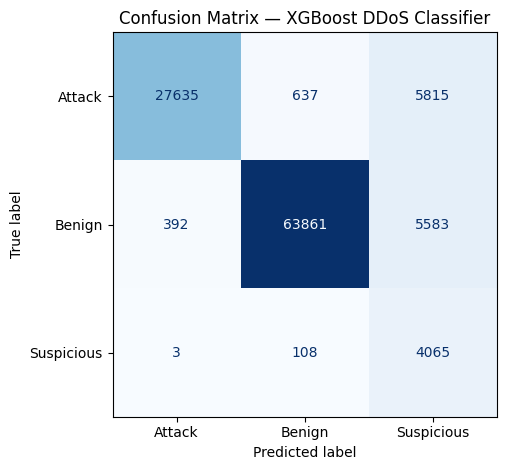

In [40]:
y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("\n=== Classification Report ===")
print(classification_report(y_test_labels, y_pred_labels, digits=4))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — XGBoost DDoS Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [41]:
f1_macro = f1_score(y_test_labels, y_pred_labels, average="macro")
f1_weighted = f1_score(y_test_labels, y_pred_labels, average="weighted")

print(f"F1 (macro): {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")

F1 (macro): 0.7513
F1 (weighted): 0.9103
